# Research Challenge

<div style="background-color: #f8d7da; border-left: 6px solid #ccc; margin: 20px; padding: 15px;">
    <strong>💡 Margaret Atwood:</strong> Every aspect of human technology has a dark side, including the bow and arrow.
</div>

## 🏅 Build your own model

It is time to go back to supervised machine learning problems.

You have been assigned one dataset from [MatBench](https://matbench.materialsproject.org) as introduced in the [Lecture slides](https://speakerdeck.com/aronwalsh/mlformaterials-challenge-25). You are free to choose and tune any machine-learning model, with any Python library, but it should be appropriate for the problem. For instance, [XGBoost](https://xgboost.readthedocs.io) could be a good starting starting point to build a regression model. You can refer back to earlier notebooks and repurpose code as needed.

You may reach the limits of computing processing power on Google Colab. Building a useful model with limited resources is a real-world skill. Using other free resources is allowed if you find an alternative service, as is running on your own computer. A model tracker such as [wandb](https://wandb.ai) could be helpful for advanced users. If you want to try a brute force approach, a library such as [Automatminer](https://hackingmaterials.lbl.gov/automatminer) may be of interest.

This notebook should be used for keeping a record of your model development, submission, and even your presentation. You are free to edit (add/remove/delete) or rearrange the cells as you see fit.

### Your details

In [ ]:
import numpy as np

# Insert your values
Name = "Yi Fang Too" # Replace with your name
CID = 2267627 # Replace with your College ID (as a numeric value with no leading 0s)

# Set a random seed using the CID value
CID = int(CID)
np.random.seed(CID)

# Print the message
print("This is the work of " + Name + " [CID: " + str(CID) + "]\n")

# Define the available groups
groups = ['A', 'B', 'C', 'D', 'E']

# Select a group based on the seeded random state
challenge_group = np.random.choice(groups)

# Print the challenge code
print("Your challenge code is " + challenge_group)

This is the work of Yi Fang Too [CID: 2267627]

Your challenge code is E


## Problem statement

You have been assigned one dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org). You should state what problem you are trying to solve and comment on the best-performing model in the benchmark.

In [ ]:
# Spare cell

In this code we try to solve a regression problem in order to predict the yield strength of steel, based on input compositions from a dataset of 312. The best-performing model in the benchmark was TPOT-Mat, which achieved a MAE of $79.9 \pm 13.6$ MPa.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from xgboost import XGBRegressor

## Data preparation

Check the data distribution and apply appropriate pre-processing steps as required.

In [ ]:
# Installation of libraries
!pip install matminer # Datasets and featurisation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.2 MB/s eta 0:00:00
  Created 

In [ ]:
# Get dataset info from matminer
from matminer.datasets import get_all_dataset_info
from matminer.datasets import load_dataset

# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code

  # A
#info = get_all_dataset_info("matbench_dielectric")

  # B
#info = get_all_dataset_info("matbench_expt_gap")

  # C
#info = get_all_dataset_info("matbench_expt_is_metal")

  # D
#info = get_all_dataset_info("matbench_glass")

  # E
info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_steels
Description: Matbench v0.1 test dataset for predicting steel yield strengths from chemical composition alone. Retrieved from Citrine informatics. Deduplicated. For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	yield strength: Target variable. Experimentally measured steel yield strengths, in MPa.
Num Entries: 312
Reference: https://citrination.com/datasets/153092/
Bibtex citations: ["@Article{Dunn2020,\nauthor={Dunn, Alexander\nand Wang, Qi\nand Ganose, Alex\nand Dopp, Daniel\nand Jain, Anubhav},\ntitle={Benchmarking materials property prediction methods: the Matbench test set and Automatminer reference algorithm},\njournal={npj Computational Materials},\nyear={2020},\nmonth={Sep},\nday={15},\nvolume={6},\nnumber={1},\npages={138},\nabstract={We present a benchmark test suite and an automated mac

In [ ]:
# Load your dataset into a pandas DataFrame
df = load_dataset("matbench_steels")

print(df)

                                           composition  yield strength
0    Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...          2411.5
1    Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....          1123.1
2    Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....          1736.3
3    Fe0.634C0.000478Mn0.000523Si0.00102Cr0.000111N...          2487.3
4    Fe0.636C0.000474Mn0.000518Si0.00101Cr0.000109N...          2249.6
..                                                 ...             ...
307  Fe0.823C0.0176Mn0.00183Si0.000198Cr0.0779Ni0.0...          1722.5
308  Fe0.823Mn0.000618Si0.00101Cr0.0561Ni0.0984Mo0....          1019.0
309  Fe0.825C0.0174Mn0.00175Si0.000201Cr0.0565Ni0.0...          1860.3
310  Fe0.858C0.0191Mn0.00194Si0.000199Cr0.0753Ni0.0...          1812.1
311  Fe0.860C0.0125Mn0.00274Si0.000198Cr0.00439Ni0....          1139.7

[312 rows x 2 columns]


Choose relevant features, which may be based on composition or structure, depending on your problem. [matminer](https://hackingmaterials.lbl.gov/matminer/) is a good place to start.

In [ ]:
# Spare cell




In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import pprint
import seaborn as sns

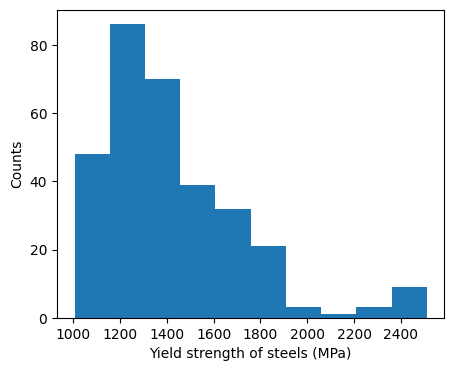

In [ ]:
og_df = df.copy()
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(df['yield strength'])
ax.set_xlabel(r'Yield strength of steels (MPa)' )
ax.set_ylabel('Counts')
plt.show()

Text(0.5, 1.0, 'Distribution of Yield Strength')

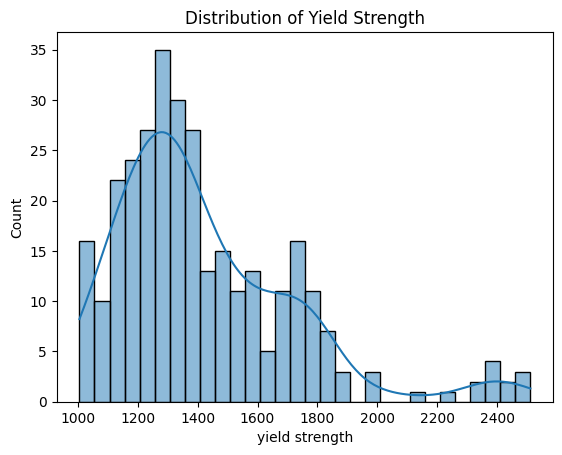

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of Yield Strength")

Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

Text(0.5, 1.0, 'Feature Importance')

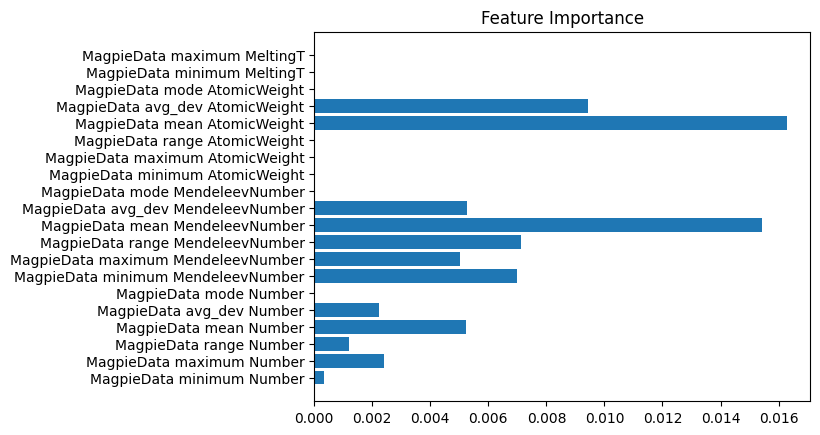

In [ ]:
# Spare cell


In [ ]:
X = df['composition'].values
y = df['yield strength'].values

from matminer.featurizers.conversions import StrToComposition

str_to_comp = StrToComposition(target_col_id='formula')
df_comp = str_to_comp.featurize_dataframe(df, col_id='composition')
df_comp.head()

StrToComposition:   0%|          | 0/312 [00:00<?, ?it/s]

,composition,yield strength,formula
0,Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...,2411.5,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)"
1,Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....,1123.1,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, N, Nb, Co, W, Al)"
2,Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....,1736.3,"(Fe, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)"
3,Fe0.634C0.000478Mn0.000523Si0.00102Cr0.000111N...,2487.3,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)"
4,Fe0.636C0.000474Mn0.000518Si0.00101Cr0.000109N...,2249.6,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)"


In [ ]:
# Featurizing
from matminer.featurizers.composition import Stoichiometry
from matminer.featurizers.composition import ElementFraction
from matminer.featurizers.composition import ValenceOrbital
from matminer.featurizers.composition import ElementProperty
from pymatgen.core import Composition

featurizer = ElementProperty.from_preset("magpie")

# Convert the 'composition' column from strings to pymatgen.core.Composition objects in the DataFrame
df["composition"] = df["composition"].apply(Composition)

# Now, featurize the DataFrame using the updated 'composition' column.
# The featurizer will now correctly find Composition objects in the specified column.
X_feat = featurizer.featurize_dataframe(df, "composition")

ElementProperty:   0%|          | 0/312 [00:00<?, ?it/s]

In [ ]:
import pandas as pd
import numpy as np

# Create a working copy of X_feat with only numerical features
X_cleaned_features = X_feat.drop(columns=["composition", "yield strength"])

# Drop any columns that contain NaN values (might occur from featurization)
X_cleaned_features = X_cleaned_features.dropna(axis=1)


<Axes: >

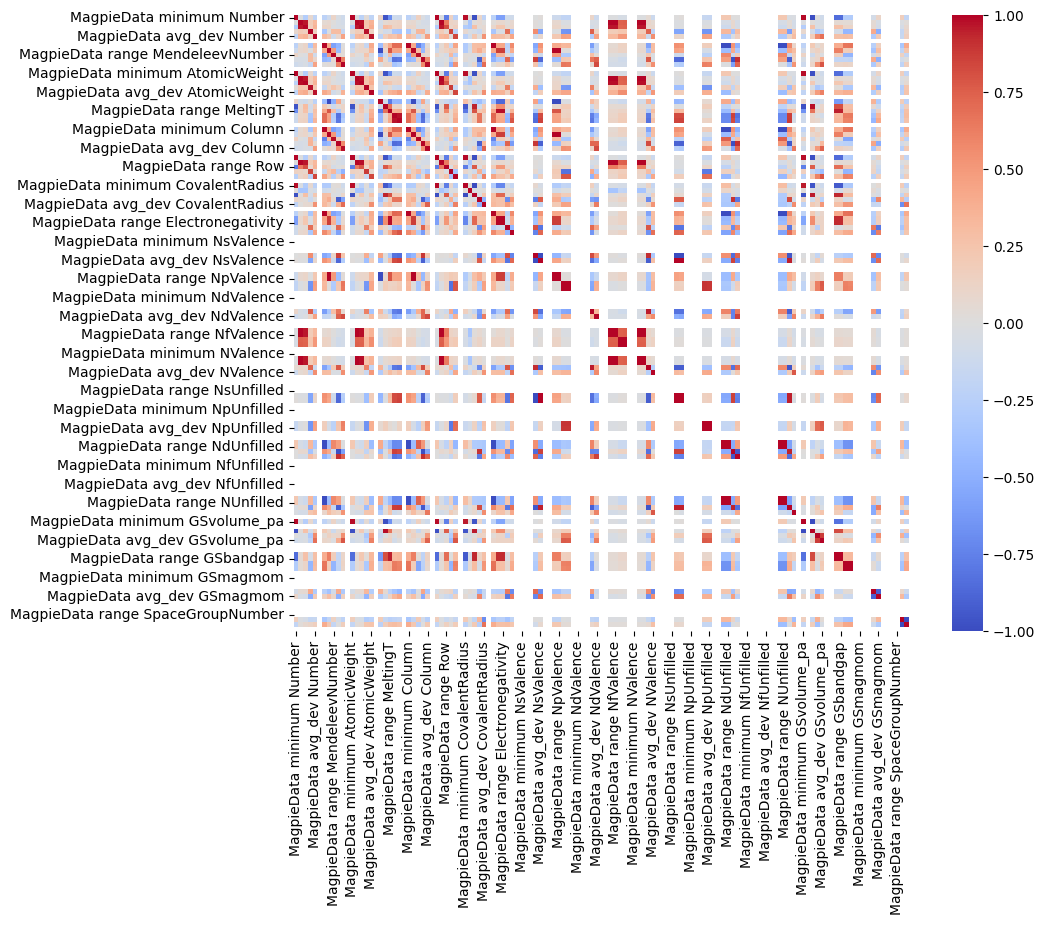

In [ ]:
corr = X.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")

In [ ]:
# Test-train split
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Use the pre-processed features from X_cleaned_features for selection
X_for_selection = X_cleaned_features.copy()
y_for_selection = X_feat["yield strength"] # y remains the original target from X_feat

selector = SelectFromModel(RandomForestRegressor(random_state=42))
selector.fit(X_for_selection, y_for_selection)

# Get the names of the selected features
selected_feature_names = X_for_selection.columns[selector.get_support()]

# Redefine the global X and y using only the selected features
X = X_for_selection[selected_feature_names]
y = y_for_selection

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

In [ ]:
# Random forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("Random Forest MAE:", mae)

MAE: 93.902246031746


In [ ]:
!pip install xgboost

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)

MAE: 94.67286086309524


In [ ]:
from sklearn.kernel_ridge import KernelRidge

kernel = KernelRidge(kernel="rbf")
kernel.fit(X_train, y_train)

preds = kernel.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)


MAE: 321.17625967512026


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1]
}

search = RandomizedSearchCV(
    XGBRegressor(),
    param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error"
)

search.fit(X_train, y_train)

print(search.best_params_)

{'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.05}


In [ ]:
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(),
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42
)

search.fit(X_train, y_train)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "max_depth": [3,4,5,6,8],
    "learning_rate": [0.01,0.05,0.1],
    "n_estimators": [200,400,600],
    "subsample": [0.7,0.8,1.0],
}

search = RandomizedSearchCV(
    XGBRegressor(),
    params,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)

{'subsample': 1.0, 'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.05}


In [ ]:
best_model = search.best_estimator_

preds = best_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)

In [ ]:
final_pred = (pred_rf + pred_xgb + pred_krr) / 3

## Model analysis and discussion

How well does your final model perform? Think of metrics and plots that are useful to dig a little deeper.

Compare against the best-performing model on the [MatBench](https://matbench.materialsproject.org) leaderboard.  With limited resources, don't expect to match this performance, but you should do better than a baseline model.

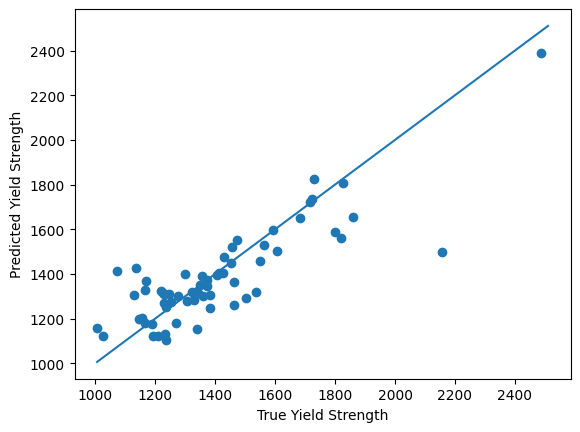

In [ ]:
plt.scatter(y_test, preds)

plt.xlabel("True Yield Strength")
plt.ylabel("Predicted Yield Strength")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()])

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X, y, cv=5,
                         scoring="neg_mean_absolute_error")

print("CV MAE:", -scores.mean())

CV MAE: 189.61356948844724


In [ ]:
from sklearn.model_selection import RepeatedKFold



In [ ]:
from sklearn.metrics import mean_absolute_error

preds = search.best_estimator_.predict(X_test)

mae = mean_absolute_error(y_test, preds)

print("Final MAE:", mae)

Final MAE: 95.26400320870536


Text(0.5, 1.0, 'Feature Importance')

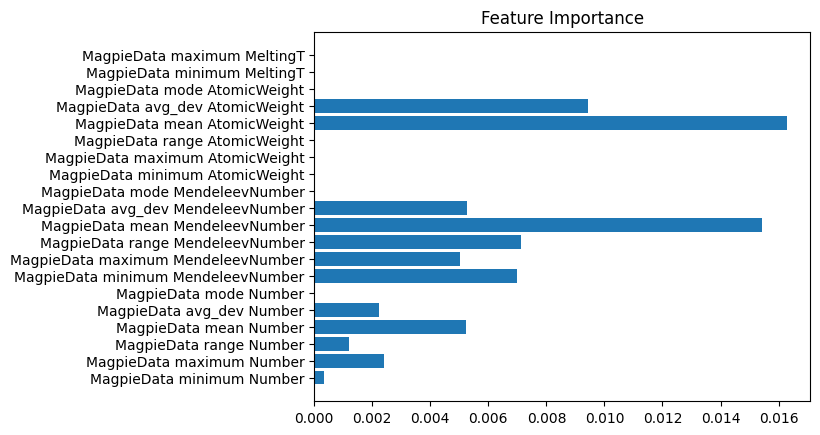

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.barh(X.columns[:20], importance[:20])
plt.title("Feature Importance")

Text(0.5, 1.0, 'Feature Importance')

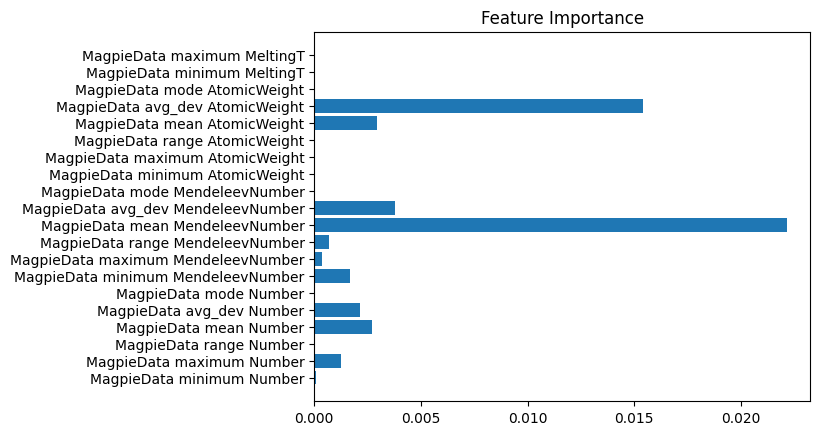

In [ ]:
importances = best_model.feature_importances_
plt.barh(X.columns[:20], importances[:20])
plt.title("Feature Importance")

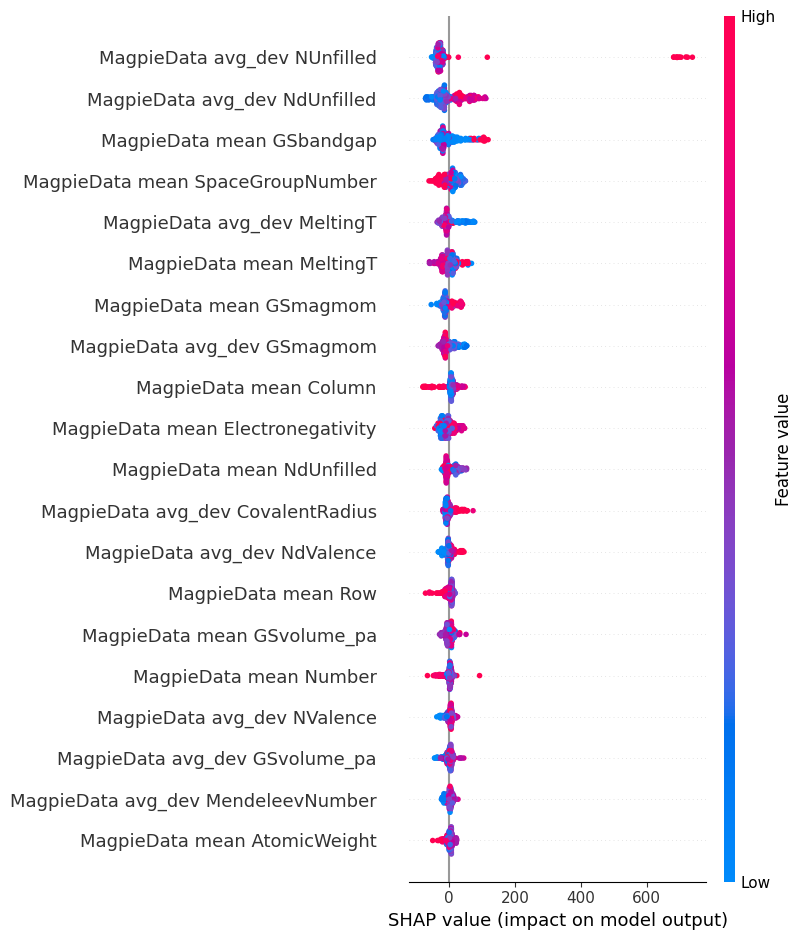

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

In [ ]:
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.kernel_ridge import KernelRidge
from xgboost import XGBRegressor

base_models = [
    ("rf", RandomForestRegressor(n_estimators=300)),
    ("xgb", XGBRegressor(n_estimators=500, learning_rate=0.05)),
    ("krr", KernelRidge(kernel="rbf"))
]

stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression()
)

stack_model.fit(X_train, y_train)
preds = stack_model.predict(X_test)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge

model = Pipeline([
    ("scaler", StandardScaler()),
    ("krr", KernelRidge(kernel="rbf"))
])

## Large Language Model (LLM) usage declaration

Acknowledge use of a generative model during your assignment. Points to consider:

* State which LLM (e.g. GPT-4, Gemini, Co-Pilot)

* Specify tasks (e.g. summarising research or code snippets)

* Were any limitations/biases noted?

* How did you ensure ethical use?

In [ ]:
# Spare cell




## ☘️ Final word

Good luck building your own model! We hope that you enjoyed the course and exercises. Dive deeper into the aspects that caught your interest. A useful starting point may be the [Resources](https://aronwalsh.github.io/MLforMaterials/Resources.html) page.

Remember that submission is on Blackboard and you should upload both the completed Juypter Notebook (`.ipynb` file), as well as your recorded narrated presentation (maximum 5 minutes; see guides on using [Zoom](https://www.youtube.com/watch?v=H9qhoAIzW3E) or [Powerpoint](https://www.youtube.com/watch?v=Y5dgwwa5XRA) for this purpose).